In [1]:
import numpy as np
import numpy.random as rd
import matplotlib.pyplot as plt
import time
import scipy.integrate as integrate
from scipy import stats

### Méthodes de Quadrature Monte Carlo
L'un des intérêts de la méthode monte carlo est l'estimation des moments de la variable d'intérêt. Dans le cas du cisaillement d'une poutre à module de Young aléatoire sur chaque sommet $E\rightsquigarrow\mathcal{N}(200,10)$.  
La méthode des rectangles, $\mathbb{E}[u]=\frac{1}{N}\sum^{N}u(e_i)$ est computationnellement lourde.
En utilisant les poids et points de Gauss Hermite, il est possible de diminuer le coût computationel pour une meilleure précision.  

**Illustrons-le**

In [29]:
def mc_classique(niter=100):
    estimateur_mc=[]
    liste_E=[]
    for i in range(niter):
        liste_E.append(rd.normal(200,10))
        estimateur_mc.append(np.mean(liste_E))
    x = np.linspace(1,niter,niter)
    #plt.plot(x,liste_E,label="Valeur")
    return estimateur_mc, [200 for i in range(niter)]
mc_classique()

([204.4365933015144,
  197.69614506715124,
  199.58753162125814,
  198.67984100750695,
  200.19533122859974,
  198.87670183129987,
  198.86394444967362,
  199.09130533993488,
  199.54778402776526,
  198.3342783701384,
  197.50954201935212,
  198.03904331420134,
  198.8796014121208,
  200.10265399961935,
  200.65509254883685,
  200.42332343579147,
  199.97183039296368,
  199.55897334632328,
  198.92489113299334,
  198.9028880675948,
  199.2766078352398,
  199.96543772922368,
  199.2490897196976,
  200.1387652695073,
  199.95993963154612,
  199.7240478029769,
  199.8954437166172,
  200.28254730220928,
  200.5155318446877,
  200.22480116623703,
  200.10950038178294,
  200.25176190754414,
  200.5479267410985,
  200.57432410974195,
  200.4116752610359,
  200.41435135268924,
  200.58772339259136,
  200.44300430746827,
  200.640981144658,
  200.92423876479745,
  200.79183219878382,
  200.67445624644608,
  200.67571091980503,
  200.47710327630523,
  200.63058287366846,
  200.64351285982914,
  

In [30]:

def mc_gausshermite_centree():
    f_n = lambda x : x/np.sqrt(np.pi)
    quadr = []
    for n in range(1,9):
        x, w = np.polynomial.hermite.hermgauss(n)
        quadr.append(0)
        for i in range(n):
            quadr[-1]+=f_n(x[i])*w[i]
    return quadr

def mc_gausshermite_normale(mu,sigma,niter):
    #Il est à noter que sigma n'a pas d'influence 
    #sur l'estimateur de l'estimateur de l'espérance
    #dans le cas de la variable aléatoire loi normale
    
    f_n = lambda x : (np.sqrt(2)*sigma*x+mu)/(np.sqrt(np.pi))
    quadr = []
    for n in range(1,niter+1):
        x, w = np.polynomial.hermite.hermgauss(n)
        quadr.append(0)
        for i in range(n):
            quadr[-1]+=f_n(x[i])*(w[i])
    return quadr


### Comparons désormais l'efficacité des deux méthodes

[200.0, 200.0, 200.0, 200.0, 200.0, 199.99999999999994, 200.0, 200.00000000000006, 200.0, 200.00000000000003]


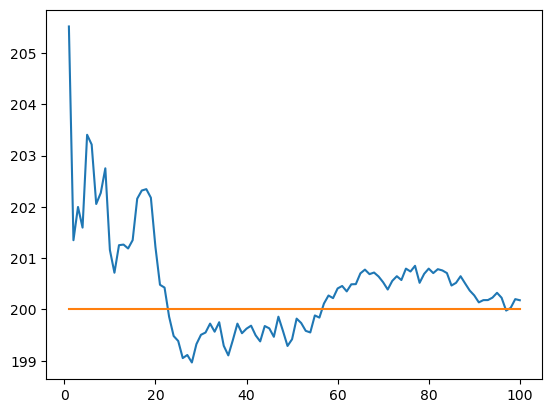

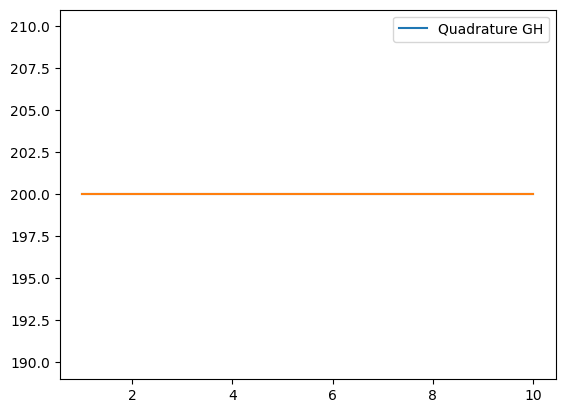

In [31]:
#Commençons par la précision des estimateurs
#Nous prenons E -> N(200,10)

estimateur_mc,moyenne = mc_classique(niter=100)
estimateur_gausshermite = mc_gausshermite_normale(200,11,10)
print(mc_gausshermite_normale(200,11,10))
x=np.linspace(1,100,100)
d=np.linspace(1,10,10)
plt.plot(x,estimateur_mc,label="MC")
plt.plot(x,moyenne,label="moyenne exacte")
plt.show()
plt.plot(d,estimateur_gausshermite,label="Quadrature GH")
plt.plot(d,[200 for i in range(10)])
plt.legend()
plt.show()


### Affichage plotlib

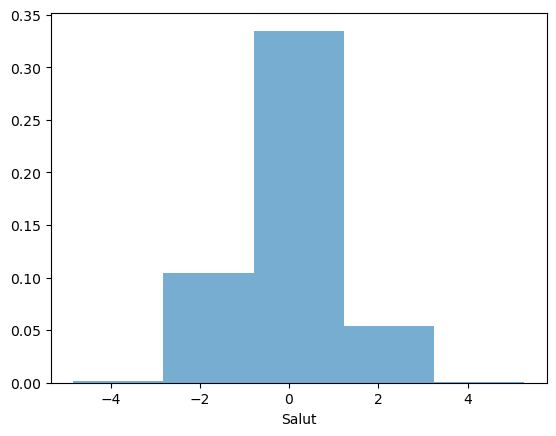

In [25]:
G = rd.normal(0,1,1000000)

plt.hist(G,bins=5,density='True',alpha=0.6)
plt.xlabel("Salut")

plt.show()

### Test de Kolmogorov-Smirnov
Le test de Kolmogorov-Smirnov est utilisé dans deux cas différents : 
+ Test sur la distribution d'un échantillon expérimental. Cela permet de conclure sur le fait qu'un échantillon suit effectivement une distribution théorique ou non, avec un niveau de confiance $\alpha$.
+ Test d'indépendance de deux lois expérimentales.
  
Nous nous concentrerons sur le premier cas.

Le test consiste à calculer la distance maximale entre la distribution expérimentale et théorique et à comparer la valeur obtenue avec les valeurs de la table de Kolmogorov.

In [18]:
class ks:
#Classe implémentant le test de Kolmogorov pour
#une loi normale de moyenne et variance donnée
#Si Dn (valeur table) > K (valeur calculée), 
#l'hypothèse est validée.

    def __init__(self,taille=10,moy=0,variance=1):
        #Définition des paramètres
        self.alpha = 0.05               #niveau de confiance
        self.size_sample = taille       #taille du sample
        self.echantillon = [0]
        self.mean= moy
        self.var = variance
        #Définition des méthodes 
        self.f_normal = lambda x : 1/(self.var*np.sqrt(2*np.pi))*np.exp(-(x-self.mean)**2/(2*self.var**2))
        self.f_uniform = lambda x : (x<1 and x > -1)*0.5
        #Définition de la table des valeurs
        self.kolmogorov_05 = [None,  # indice 0 inutilisé
    0.975, 0.84189, 0.7076, 0.62394, 0.56328, 0.51926, 0.48342, 0.45427, 0.43001, 0.40925,
    0.39122, 0.37543, 0.36143, 0.34890, 0.33750, 0.32733, 0.31796, 0.30936, 0.30143, 0.29408,
    0.28724, 0.28087, 0.27490, 0.26931, 0.26404, 0.25908, 0.25438, 0.24993, 0.24571, 0.24170,
    0.23788, 0.23424, 0.23076, 0.22743, 0.22425, 0.22119, 0.21826, 0.21544, 0.21273, 0.21012
        ]
    def set_param(self,value1,value2):
        self.alpha = value1
        self.size_sample = value2

    def tirage_aleatoire(self,mean,var):
        echantillon_int = []
        for i in range(self.size_sample):
            echantillon_int.append(rd.normal(mean,var))
        echantillon_int.sort()
        self.echantillon = echantillon_int

    def kstest(self):
        calcul_max = 0
        #for j in range(self.size_sample):
        #    if (j/self.size_sample-self.f_normal(self.echantillon[j])) > calcul_max :
        #        calcul_max = (j/self.size_sample)-self.f_normal(self.echantillon[j])
        #    elif (self.f_normal(self.echantillon[j])-(j-1)/self.size_sample) > calcul_max :
        #        calcul_max = self.f_normal(self.echantillon[j])-(j-1)/self.size_sample
        for j in range(self.size_sample-1):
            if np.abs(self.F(self.echantillon[j])-self.f_normal(self.echantillon[j])) > calcul_max :
                calcul_max = np.abs(self.F(self.echantillon[j])-integrate.quad(self.f_normal,-np.inf,self.echantillon[j]))
                print("Nouveau max : ",calcul_max," avec indice : ",j, " et [x_j]= ",self.echantillon[j])
            elif np.abs(self.F(self.echantillon[j])-self.f_normal(self.echantillon[j+1])) > calcul_max : 
                calcul_max = np.abs(self.F(self.echantillon[j])-integrate.quad(self.f_normal,-np.inf,self.echantillon[j+1]))  
                print("Nouveau max : ",calcul_max," avec indice : ",j, " et [x_j]= ", self.echantillon[j])
        print( "Voici le résultat du test :",calcul_max < self.kolmogorov_05[self.size_sample])
        return calcul_max
        
    def F(self,x):
        compteur = 0
        while x > self.echantillon[compteur] and compteur < len(self.echantillon)-1:
            compteur += 1
        return compteur/len(self.echantillon)
        
    def affichage(self):
        print(len(self.echantillon))
        #plt.hist(self.echantillon,bins=20,density=True,alpha=0.5)
        plt.plot(self.echantillon,[self.F(-5+10*i/self.size_sample) for i in range(self.size_sample)],label="echantillon")
        #plt.plot(self.echantillon,[integrate.quad(f_normal,-np.inf,-5+10*i/self.size_sample)[0] for i in range(self.size_sample)],label="loi normale")
        #plt.plot(np.linspace(-5,5,len(self.echantillon)),[self.F(-5+10*i/self.size_sample) for i in range(self.size_sample)],label="echantillon")
        #plt.plot(np.linspace(-5,5,self.size_sample),[integrate.quad(f_normal,-np.inf,-5+10*i/self.size_sample)[0] for i in range(self.size_sample)],label="loi normale")
        plt.legend()
        plt.show()
        

#test = ks(20,0,1)
#test.tirage_aleatoire(0,1)

#test.affichage()
#test.kstest()


#####################
#Comparaison avec la 
#bibliothèque scipy
#####################
#x = stats.norm.rvs(size=100, random_state=rng)
#x = rd.uniform(0,1,100)

#stats.kstest(x, stats.norm.cdf)
#g = rd.normal(0,1,20)
#a = [g[i] for i in range(len(g))]
#a.sort()
#print(a)
#Y = [F(-5+0.1*i,a) for i in range(100)]
#plt.plot(np.linspace(-5,5,100),Y,label="echantillon")
#plt.plot(x1,liste_f,label="int f normale")
#plt.legend()
#plt.show()

#def kstest(nb):
#    alpha = 0.05
#    G = tirage_aleatoire(nb)
#    G.sort()
#    calcul_max = 0
#    for j in range(nb):
#        if (j/nb-f_normal(G[j])) > calcul_max :
#            calcul_max = j/nb-f_normal(G[j])
#        elif (f_normal(G[j])-(j-1)/nb) > calcul_max :
#            calcul_max = f_normal(G[j])-(j-1)/nb
#    return calcul_max





KstestResult(statistic=0.5071481281637283, pvalue=2.3366192695321297e-24, statistic_location=0.017918659001923687, statistic_sign=-1)

(2.88, 2.96)

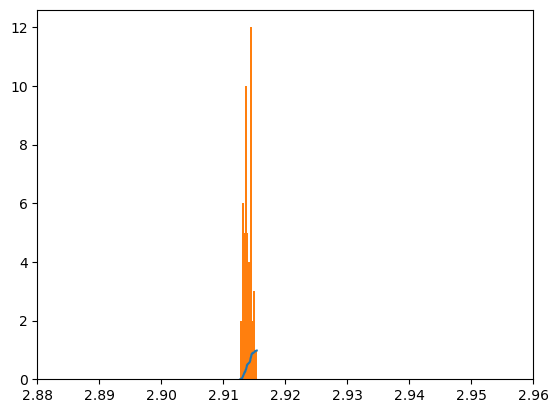

In [24]:
#Loi normale
echantillon = rd.normal(2.914,0.0006458,50)
echantillon.sort()
f = [i/len(echantillon) for i in range(len(echantillon))]
plt.plot(echantillon,f)
plt.hist(echantillon,density=False)
plt.xlim(2.88, 2.96)

### Comparaison Covariance Convolution spatiale / Cholesky
Le but ici est de comparer les constructions de variables aléatoires corrélées par méthode directe (Cholesky) (à partir de la matrice de covariance) et par convolution spatiale. 

On reste dans le cas 1D.

On convolue sur l'ensemble de l'espace, qui est un maillage uniforme d'une droite.




Pour vérifier l'implémentation du code, on peut calculer la covariance des variables aléatoires ainsi obtenues à l'aide d'estimateur de covariance E[(X-E[X])(Y-E[Y])] donc par monte carlo.

In [109]:
print(np.linspace(0,2,2))

[0. 2.]


In [12]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
from numpy.linalg import cholesky


  
def gauss_cholesky(n,echantillon):
    """
    Méthode de construction du champs aléatoire par méthode de Cholesky
    Cette méthode est intérmédiaire, et utilisée par la fonction monte_carlo ci-bas
    n : taille du maillage
    echantillon : réalisation d'un bruit blanc aléatoire de taille n
    sortie W : réalisation du champs aléatoire 
    """
    #Variable corrélée par cholesky
    x = np.linspace(0,3,n)
    #pas = 20/(n-1)
    pas = (x[-1]-x[0])/(n-1)                                 #pas correspondance convolution

    #Construction de la matrice de covariance
    cov = np.eye(n)
    for i in range(len(cov)):
        for j in range(len(cov)):
            if i != j :
                cov[i,j] = np.exp(-(1/4)*((pas*(i-j))**2))              #changer -1 en -1/4 pour la correspondance avec la convolution 

    #méthode de cholesky
    A = cholesky(cov)
    G = echantillon
    #calcul des variables aléatoires
    W = np.dot(A,G)
    return W.tolist()
    
def gauss_convolution(n,echantillon):
    """
    Méthode de construction du champs aléatoire par Convolution spatiale
    Cette méthode est intérmédiaire, et utilisée par la fonction monte_carlo ci-bas
    n : taille du maillage
    echantillon : réalisation d'un bruit blanc aléatoire de taille n
    sortie Y : réalisation du champs aléatoire 
    """
    x = np.linspace(0,3,n)   #Maillage
    
    pas = (np.sqrt(1)/np.sqrt(1))*(x[-1]-x[0])/(n-1)                #pas correspondance cholesky
    h = echantillon
    Y=[0]*len(h)
    #noyau de convolution
    f = lambda z: (1/np.sqrt(1))*np.exp((-1)*((pas*z)**2))
    #convolution
    for i in range(n):
        den = 0
        for j in range(n):
            #les racines permettent de conserver la variance
            #d'origine dans la convolution
            Y[i] += h[j]*np.sqrt(f((j-i)))

            den += f((j-i))
        Y[i] = Y[i]/(np.sqrt(den))
        
    return Y

def eq_gauss_convolution(n):
    """
    Méthode de construction du champs aléatoire par méthode de Convolution
    Le noyau de convolution n'est ici pas gaussien mais exponentiel
    n : taille du maillage
    sortie Y : réalisation du champs aléatoire 
    """
    #Variable corrélée par convolution
    x = np.linspace(0,3,n)
    pas = (np.sqrt(2)/np.sqrt(1))**2*x[-1]/(n-1)
    h = rd.normal(0,1,n)
    Y=[0]*len(h)
    #noyau de convolution
    f = lambda x: np.exp(-x)*1/np.sqrt(np.abs(x))
    #convolution
    for i in range(n):
        den = 0
        for j in range(n):
            #les racines permettent de conserver la variance
            #d'origine dans la convolution
            Y[i] += h[j]*np.sqrt(f((j-i)))
            den += f((j-i))
        Y[i] = Y[i]/(np.sqrt(den))
        
    return Y

def estimateur_cov(ech1,ech2):
    """
    Méthode de calcul de l'estimateur de la corrélation entre deux échantillons
    ech1 : premier échantillon d'une réalisation d'une loi aléatoire
    ech2 : deuxième échantillon d'une réalisation d'une loi aléatoire
    sortie : estimateur/n : facteur de covariance
    """
    if len(ech1) != len(ech2):
        print("Erreur sur les tailles des échantillons.")
        return None
        
    n=len(ech1)
    estimateur = 0
    mean_ech1 = np.mean(ech1)
    mean_ech2 = np.mean(ech2)
    
    for i in range(n):
        estimateur += (ech1[i]-mean_ech1)*(ech2[i]-mean_ech2)
    print("Ceci est l'estimateur/n :", estimateur/n)
    
    return estimateur/n



def estimateur_mat_cov(ech):
    """
    Méthode de calcul de l'estimateur de la matrice de covariance spatiale d'un échantillon
    ech : plusieurs réalisations d'un champs aléatoire, par méthode monte carlo
    sortie Q : estimateur de la matrice de covariance spatiale du champs aléatoire 
    """
    
    ech = np.array(ech)
    n_mc,n_real=ech.shape      #n_mc = nombre de réalisation monte carlo, n_real = taille de chaque échantillon

    Q = np.empty((len(ech[0]),len(ech[0])))  #Initialisation de la matrice de covariance
    
    #calcul de la moyenne des réalisations de l'échantillon mc
    x_barre = np.mean(ech,axis=0)
    print("x_barre:",x_barre)
    #centrage de l'échantillon
    x_centre = ech-x_barre
    #estimateur de la matrice de covariance
    Q = (x_centre.T @ x_centre) / (n_mc - 1)
    return Q

def monte_carlo_chol(nmc,n_sampl):
    """
    Méthode de monte_carlo pour la méthode de Cholesky
    nmc : nombre de simulations monte carlo requises
    n_sampl : taille de chaque échantillon requise
    sortie ech : liste des réalisations par convolution; ech[i] est une réalisation d
                'un champs aléatoire
    """
    ech = []
    for i in range(nmc):
        echantillon = rd.normal(0,1,n_sampl)
        ech.append(gauss_cholesky(n_sampl,echantillon))
    return ech

def monte_carlo_conv(nmc,n_sampl):
    """
    Méthode de monte_carlo pour la convolution
    nmc : nombre de simulations monte carlo requises
    n_sampl : taille de chaque échantillon requise
    sortie ech : liste des réalisations par convolution; ech[i] est une réalisation d
                'un champs aléatoire
    """
    ech = []
    for i in range(nmc):
        echantillon = rd.normal(0,1,n_sampl)
        ech.append(gauss_convolution(n_sampl,echantillon))
    return ech

def monte_carlo(nmc,n_sampl):
    ech_conv = []
    ech_chol = []
    for i in range(nmc):
        ech = rd.normal(0,1,n_sampl)
        ech_chol.append(gauss_cholesky(n_sampl,ech))
        ech_conv.append(gauss_convolution(n_sampl,ech))
    return ech_chol, ech_conv
    
def monte_carlo_eq_conv(self,nmc,n_sampl):
    ech = []
    for i in range(nmc):
        ech.append(eq_gauss_convolution(n_sampl))
    return ech

#####################
#Visualisation et comparaisons des résultats
#####################

A = monte_carlo_chol(1000,2)
B = monte_carlo_conv(1000,2)
C = estimateur_mat_cov(A)
D = estimateur_mat_cov(B)
print(" 2 Chol : ",C)
print("\n")
print("2 Conv : ",D)
print("Erreur : ",C-D)

print("\n\n\n")
E,F = monte_carlo(10000,3)
G = estimateur_mat_cov(E)
H = estimateur_mat_cov(F)
print("3Chol : ",G)
print("3Conv : ",H)
print("Erreur : ",G-H)

print("\n\n\n")
E,F = monte_carlo(10000,4)
G = estimateur_mat_cov(E)
H = estimateur_mat_cov(F)
print("4Chol : ",G)
print("4Conv : ",H)
print("Erreur : ",G-H)

print("\n\n\n")
E,F = monte_carlo(10000,6)
G = estimateur_mat_cov(E)
H = estimateur_mat_cov(F)
print("6Chol : ",G)
print("6Conv : ",H)
print("Erreur : ",G-H)

print("\n\n\n")
E,F = monte_carlo(10000,7)
G = estimateur_mat_cov(E)
H = estimateur_mat_cov(F)
print("7Chol : ",G)
print("7Conv : ",H)
print("Erreur : ",G-H)

print("\n\n\n")
E,F = monte_carlo(10000,8)
G = estimateur_mat_cov(E)
H = estimateur_mat_cov(F)
print("8Chol : ",G)
print("8Conv : ",H)
print("Erreur : ",G-H)

print("\n\n\n")
E,F = monte_carlo(10000,9)
G = estimateur_mat_cov(E)
H = estimateur_mat_cov(F)
print("9Chol : ",G)
print("9Conv : ",H)
print("Erreur : ",G-H)

print("\n\n\n")
E,F = monte_carlo(10000,10)
G = estimateur_mat_cov(E)
H = estimateur_mat_cov(F)
print("10Chol : ",G)
print("10Conv : ",H)
print("Erreur : ",G-H)
# G = rd.normal(0,1,n)
# H = test_gauss.gauss_cholesky(n,G)
# x = np.linspace(-10,10,n)
# plt.plot(x,H,marker='o')
# plt.xlabel("noeuds maillage")
# plt.ylabel("réalisation H(x,theta)")
# plt.title("Cholesky")
# plt.show()
# H_c = test_gauss.gauss_convolution(n,G)
# plt.plot(x,H_c,marker='o')
# plt.xlabel("noeuds maillage")
# plt.ylabel("réalisation H(x,theta)")
# plt.title("Convolution")
# plt.show()
# W = monte_carlo_chol(10000,3)
# Q = estimateur_mat_cov(W)
# Y = monte_carlo_conv(10000,3)
# Z = estimateur_mat_cov(Y)
# A10,B10 = monte_carlo(10,5)
# A100,B100 = monte_carlo(100,5)
# A1000,B1000 = monte_carlo(1000,3)
# A10000,B10000 = monte_carlo(10000,5)
# A100000,B100000 = monte_carlo(100000,5)
# Q_chol10 = estimateur_mat_cov(A10)
# Q_conv10= estimateur_mat_cov(B10)
# Q_chol100 = estimateur_mat_cov(A100)
# Q_conv100 = estimateur_mat_cov(B100)
# Q_chol1000 = estimateur_mat_cov(A1000)
# Q_conv1000 = estimateur_mat_cov(B1000)
# Q_chol10000 = estimateur_mat_cov(A10000)
# Q_conv10000 = estimateur_mat_cov(B10000)
# Q_chol100000 = estimateur_mat_cov(A100000)
# Q_conv100000 = estimateur_mat_cov(B100000)

# n_list = [10, 100, 1000, 10000, 100000]
# Q_chol_list = [Q_chol10, Q_chol100, Q_chol1000, Q_chol10000, Q_chol100000]
# Q_conv_list = [Q_conv10, Q_conv100, Q_conv1000, Q_conv10000, Q_conv100000]

# y = []
# for n, Q_chol, Q_conv in zip(n_list, Q_chol_list, Q_conv_list):
#     erreur = Q_chol - Q_conv
#     y.append(erreur[0, 1])
#     print(f"Erreur entre les estimateurs pour n={n} :\n{erreur}")

# # Affichage du graphe
# print("Estimateur chol :\n",Q_chol1000)
# print("Estimateur conv :\n",Q_conv1000)
# print("Erreur entre les estimateurs :",Q_chol1000-Q_conv1000)
# plt.plot(n_list, y, marker='o')
# plt.xlabel("Nombre d'itérations Monte Carlo")
# plt.ylabel("Erreur (coefficient [0,1])")
# plt.xscale('log')
# plt.title("Erreur entre estimateurs en fonction du nombre d'itérations")
# plt.grid()
# plt.show()

x_barre: [ 0.00231157 -0.05277276]
x_barre: [0.01793559 0.05269415]
 2 Chol :  [[0.98457156 0.12717983]
 [0.12717983 0.92568491]]


2 Conv :  [[1.00141014 0.02601592]
 [0.02601592 0.94187421]]
Erreur :  [[-0.01683858  0.10116392]
 [ 0.10116392 -0.0161893 ]]




x_barre: [-0.00513062  0.00016156 -0.0056058 ]
x_barre: [-0.00382104 -0.00090867 -0.00794168]
3Chol :  [[0.99195269 0.54403639 0.09608602]
 [0.54403639 0.97281455 0.56166349]
 [0.09608602 0.56166349 1.0036558 ]]
3Conv :  [[0.97772523 0.54001551 0.11637386]
 [0.54001551 0.98729887 0.56676492]
 [0.11637386 0.56676492 1.00894735]]
Erreur :  [[ 0.01422746  0.00402088 -0.02028784]
 [ 0.00402088 -0.01448433 -0.00510143]
 [-0.02028784 -0.00510143 -0.00529155]]




x_barre: [ 0.00699078 -0.00323031 -0.00904089 -0.00262375]
x_barre: [-0.00127339 -0.00698254 -0.00248884  0.00562862]
4Chol :  [[0.99006224 0.77421063 0.36905636 0.10662975]
 [0.77421063 0.99334179 0.77687885 0.37165157]
 [0.36905636 0.77687885 0.99956762 0.78357389]
 [0.1066

In [ ]:
Q = [[ 5.51964014e-03  1.37090149e-02  1.86404065e-02  1.51398959e-02
   5.06256818e-03 -6.65245287e-03 -1.14459578e-02 -6.76663316e-03
  -1.31779439e-03  6.76219338e-05]
 [ 1.37090149e-02  4.62787421e-02  9.03380325e-02  1.00340110e-01
   5.13324866e-02 -1.48762280e-02 -3.97426024e-02 -2.08376251e-02
  -2.48473844e-03  9.66182994e-04]
 [ 1.86404065e-02  9.03380325e-02  2.48196546e-01  3.73677915e-01
   2.90196620e-01  8.11390635e-02 -2.96861316e-02 -1.78149872e-02
   4.60765775e-03  4.76053803e-03]
 [ 1.51398959e-02  1.00340110e-01  3.73677915e-01  7.62566696e-01
   8.52807368e-01  5.09381184e-01  1.60214395e-01  3.98468900e-02
   2.24873519e-02  1.17558301e-02]
 [ 5.06256818e-03  5.13324866e-02  2.90196620e-01  8.52807368e-01
   1.36273317e+00  1.19145273e+00  5.77286917e-01  1.57760474e-01
   3.27980381e-02  1.21527719e-02]
 [-6.65245287e-03 -1.48762280e-02  8.11390635e-02  5.09381184e-01
   1.19145273e+00  1.42448923e+00  9.22569944e-01  3.15538992e-01
   5.32528984e-02  7.29726439e-03]
 [-1.14459578e-02 -3.97426024e-02 -2.96861316e-02  1.60214395e-01
   5.77286917e-01  9.22569944e-01  7.97995752e-01  3.70012176e-01
   8.71099562e-02  1.02810623e-02]
 [-6.76663316e-03 -2.08376251e-02 -1.78149872e-02  3.98468900e-02
   1.57760474e-01  3.15538992e-01  3.70012176e-01  2.38083819e-01
   8.20460084e-02  1.50611478e-02]
 [-1.31779439e-03 -2.48473844e-03  4.60765775e-03  2.24873519e-02
   3.27980381e-02  5.32528984e-02  8.71099562e-02  8.20460084e-02
   4.15626673e-02  1.13853520e-02]
 [ 6.76219338e-05  9.66182994e-04  4.76053803e-03  1.17558301e-02
   1.21527719e-02  7.29726439e-03  1.02810623e-02  1.50611478e-02
   1.13853520e-02  4.32228948e-03]]

### Affichage des réalisations de la solution SSFEM
Une fois la solution SSFEM calculée, il est pertinent de réaliser un traitement statistique en considérant des réalisations de la solution aléatoire. Cela se fait donc par la méthode indirecte de simulation Monte Carlo.